# Mellum-4b Data Inspection

Dedicated data-inspection notebook for Mellum-4b, aligned with the workflow used in `full_precision` and `quantization`.

Expected files in `./data/`:
- `pre-train_tags.csv`
- `fine-tune_tags.csv`

In [39]:
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from cycler import cycler

project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'experiments' / 'utils').exists()), None)
if project_root is None:
    raise RuntimeError('Project root not found from current working directory.')
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from experiments.utils.confidence_intervals import wilson_confint

line_cycler = (
    cycler(color=['#E69F00', '#56B4E9', '#009E73', '#0072B2', '#D55E00', '#CC79A7', '#F0E442'])
    + cycler(linestyle=['-', '--', '-.', ':', '-', '--', '-.'])
)
plt.rc('axes', prop_cycle=line_cycler)

CAT_LABELS = {
    'c': 'Code',
    'di': 'Dicts',
    'do': 'Docs',
    'l': 'License',
    't': 'Testing',
}


NOTEBOOK_DATA_DIR = project_root / 'experiments' / 'mellum4b' / 'data-inspection' / 'data'
MELLUM_MEM_DIR = project_root / 'experiments' / 'mellum4b' / 'memorization'
BASE_TAG_DIRS = [
    project_root / 'experiments' / 'full_precision' / 'data-inspection' / 'data',
    project_root / 'experiments' / 'quantization' / 'data-inspection' / 'data',
    project_root / 'experiments' / 'lora' / 'data-inspection' / 'data',
]


def resolve_data_file(filename):
    candidates = [
        Path(filename),
        Path.cwd() / filename,
        Path.cwd() / 'data' / filename,
        Path.cwd() / 'experiments' / 'mellum4b' / 'data-inspection' / 'data' / filename,
        NOTEBOOK_DATA_DIR / filename,
        *[d / filename for d in BASE_TAG_DIRS],
    ]

    checked = []
    for p in candidates:
        p = p.resolve()
        if p in checked:
            continue
        checked.append(p)
        if p.exists():
            return p

    checked_str = '\n'.join([f' - {p}' for p in checked])
    raise FileNotFoundError(
        f"Missing required data file '{filename}'. Checked:\n{checked_str}"
    )


def _template_tags_df(filename):
    src = resolve_data_file(filename)
    return pd.read_csv(src, index_col=0), src


def _align_and_attach_metrics(tags_df, metrics_df, metric_cols):
    out = tags_df.copy()
    out = out.drop(columns=[c for c in metric_cols if c in out.columns], errors='ignore')

    metrics_slice = metrics_df[metric_cols].copy()
    if len(out) == len(metrics_slice):
        return pd.concat([out.reset_index(drop=True), metrics_slice.reset_index(drop=True)], axis=1)

    key_cols = [c for c in ['prefix_100', 'suffix'] if c in out.columns and c in metrics_df.columns]
    if len(key_cols) == 2 and int(metrics_df[key_cols].duplicated().sum()) == 0:
        merged = out.merge(metrics_df[key_cols + metric_cols], on=key_cols, how='left')
        missing = int(merged[metric_cols[0]].isna().sum()) if metric_cols else 0
        if missing > 0:
            print(f'Warning: {missing} rows could not be matched on {key_cols}.')
        return merged

    n = min(len(out), len(metrics_slice))
    print(f'Warning: falling back to positional align on first {n} rows.')
    out = out.reset_index(drop=True)
    out.loc[: n - 1, metric_cols] = metrics_slice.iloc[:n].to_numpy()
    return out


def ensure_mellum_tag_csvs():
    NOTEBOOK_DATA_DIR.mkdir(parents=True, exist_ok=True)

    pre_target = NOTEBOOK_DATA_DIR / 'pre-train_tags.csv'
    ft_target = NOTEBOOK_DATA_DIR / 'fine-tune_tags.csv'

    pre_parquet = MELLUM_MEM_DIR / 'attack_mem_plen' / 'attack_mem_plen.parquet'
    dedup_d3_parquet = MELLUM_MEM_DIR / 'attack_mem_dedup' / 'attack_mem_dedup_3.parquet'
    dedup_g3_parquet = MELLUM_MEM_DIR / 'attack_mem_dedup' / 'attack_mem_dedup_g3.parquet'

    if not pre_parquet.exists():
        raise FileNotFoundError(f'Missing Mellum parquet: {pre_parquet}')
    if not dedup_d3_parquet.exists() and not dedup_g3_parquet.exists():
        raise FileNotFoundError(
            f'Missing Mellum dedup parquet. Expected one of: {dedup_d3_parquet} or {dedup_g3_parquet}'
        )

    pre_df, pre_src = _template_tags_df('pre-train_tags.csv')
    pre_metrics = pd.read_parquet(pre_parquet)
    pre_metric_cols = [
        c for c in pre_metrics.columns
        if re.match(r'^me4b_ep[03]_p(100|150|200|250)_(em|bleu|meteor|rougeL)$', c)
    ]
    if not pre_metric_cols:
        raise KeyError(f'No me4b pre-train metric columns found in {pre_parquet}')
    pre_out = _align_and_attach_metrics(pre_df, pre_metrics, sorted(pre_metric_cols))
    pre_out.to_csv(pre_target)
    print(f'Prepared {pre_target} from template {pre_src}')

    ft_df, ft_src = _template_tags_df('fine-tune_tags.csv')
    if dedup_d3_parquet.exists():
        ft_metrics = pd.read_parquet(dedup_d3_parquet)
        ft_regex = r'^me4b_ep[03]_d3_(em|bleu|meteor|rougeL)$'
        scope_used = 'd3'
    else:
        ft_metrics = pd.read_parquet(dedup_g3_parquet)
        ft_regex = r'^me4b_ep[03]_dg3_(em|bleu|meteor|rougeL)$'
        scope_used = 'dg3'

    ft_metric_cols = [c for c in ft_metrics.columns if re.match(ft_regex, c)]
    if not ft_metric_cols:
        raise KeyError('No me4b fine-tune metric columns found in dedup parquet.')
    ft_out = _align_and_attach_metrics(ft_df, ft_metrics, sorted(ft_metric_cols))
    ft_out.to_csv(ft_target)
    print(f'Prepared {ft_target} from template {ft_src} using scope {scope_used}')


def load_tags(filename):
    p = resolve_data_file(filename)
    df = pd.read_csv(p, index_col=0)
    if 'agree' in df.columns:
        df = df[df['agree'] == 1].copy()
    if 'Cat' not in df.columns:
        raise KeyError(f"'Cat' column is required in {p}.")

    df['Cat'] = df['Cat'].astype(str).str.strip().str.lower()
    return df


def resolve_model_prefix(df, candidates=('me4b', 'mellum4b')):
    for prefix in candidates:
        if any(col.startswith(f'{prefix}_') for col in df.columns):
            return prefix
    raise KeyError(
        f'No Mellum prefix found. Tried {candidates}. '
        'Expected columns like me4b_ep0_p100_em or mellum4b_ep0_p100_em.'
    )


def resolve_metric_col(df, model_prefix, epoch, scope_candidates):
    for scope in scope_candidates:
        col = f'{model_prefix}_{epoch}_{scope}_em'
        if col in df.columns:
            return col, scope
    tried = [f'{model_prefix}_{epoch}_{scope}_em' for scope in scope_candidates]
    raise KeyError(f'Missing EM metric column. Tried: {tried}')


def ordered_categories(df, preferred=('c', 'di', 'do', 'l', 't')):
    cats = sorted(set(df['Cat'].dropna().tolist()))
    ordered = [c for c in preferred if c in cats]
    ordered.extend([c for c in cats if c not in ordered])
    return ordered


def build_phase_tables(df, before_col, after_col, cat_order):
    totals = df.groupby('Cat').size().reindex(cat_order).fillna(0).astype(int)

    before_hits = (
        df[df[before_col] == 1]
        .groupby('Cat')
        .size()
        .reindex(cat_order)
        .fillna(0)
        .astype(int)
    )
    after_hits = (
        df[df[after_col] == 1]
        .groupby('Cat')
        .size()
        .reindex(cat_order)
        .fillna(0)
        .astype(int)
    )

    absolute = pd.DataFrame({'ep0': before_hits, 'ep3': after_hits}, index=cat_order)
    percentage = absolute.div(totals.replace(0, np.nan), axis=0) * 100.0

    ci_low = pd.DataFrame(index=cat_order, columns=absolute.columns, dtype=float)
    ci_high = pd.DataFrame(index=cat_order, columns=absolute.columns, dtype=float)

    for cat in cat_order:
        nobs = int(totals.loc[cat])
        if nobs <= 0:
            continue
        for phase in absolute.columns:
            successes = int(absolute.loc[cat, phase])
            low, high = wilson_confint(successes, nobs, alpha=0.05)
            ci_low.loc[cat, phase] = low * 100.0
            ci_high.loc[cat, phase] = high * 100.0

    return totals, absolute, percentage, ci_low, ci_high


def ci_annotation(percentage, ci_low, ci_high, decimals=1):
    annot = pd.DataFrame(index=percentage.index, columns=percentage.columns, dtype=object)
    for row in percentage.index:
        for col in percentage.columns:
            value = percentage.loc[row, col]
            if pd.isna(value):
                annot.loc[row, col] = '-'
            else:
                annot.loc[row, col] = (
                    f"{value:.{decimals}f}\n"
                    f"[{ci_low.loc[row, col]:.{decimals}f}, {ci_high.loc[row, col]:.{decimals}f}]"
                )
    return annot


def human_category_labels(cat_order):
    return [CAT_LABELS.get(cat, cat.upper()) for cat in cat_order]


def plot_heatmap(df_values, y_labels, title, out_pdf, annot=True, fmt='.1f', vmin=None, vmax=None, xlabel='Epoch'):
    fig, ax = plt.subplots(figsize=(6.2, 5.0))
    sns.heatmap(
        df_values,
        annot=annot,
        fmt=fmt,
        cmap='Blues',
        cbar=True,
        ax=ax,
        vmin=vmin,
        vmax=vmax,
        annot_kws={'fontsize': 8},
    )
    if title:
        ax.set_title(title)
    ax.set_ylabel('Categories')
    ax.set_xlabel(xlabel)
    ax.set_yticklabels(y_labels, rotation=0)
    ax.set_xticklabels([str(c) for c in df_values.columns], rotation=0)
    fig.tight_layout()
    fig.savefig(out_pdf, format='pdf', bbox_inches='tight')
    plt.show()

## Load Data

In [40]:
ensure_mellum_tag_csvs()

pre_training_tags = load_tags('pre-train_tags.csv')
fine_tuning_tags = load_tags('fine-tune_tags.csv')

MODEL_PREFIX_PRE = resolve_model_prefix(pre_training_tags)
MODEL_PREFIX_FT = resolve_model_prefix(fine_tuning_tags)

print('Detected model prefix (pre-train tags):', MODEL_PREFIX_PRE)
print('Detected model prefix (fine-tune tags):', MODEL_PREFIX_FT)

Prepared /Users/fabiosalerno/Documents/main/mem-quant/experiments/mellum4b/data-inspection/data/pre-train_tags.csv from template /Users/fabiosalerno/Documents/main/mem-quant/experiments/mellum4b/data-inspection/data/pre-train_tags.csv
Prepared /Users/fabiosalerno/Documents/main/mem-quant/experiments/mellum4b/data-inspection/data/fine-tune_tags.csv from template /Users/fabiosalerno/Documents/main/mem-quant/experiments/mellum4b/data-inspection/data/fine-tune_tags.csv using scope d3
Detected model prefix (pre-train tags): me4b
Detected model prefix (fine-tune tags): me4b


## Pre-train Tags (prefix-length setting)

In [41]:
pre_ep0_col, pre_scope = resolve_metric_col(pre_training_tags, MODEL_PREFIX_PRE, 'ep0', ['p100'])
pre_ep3_col, _ = resolve_metric_col(pre_training_tags, MODEL_PREFIX_PRE, 'ep3', [pre_scope])

pre_cat_order = ordered_categories(pre_training_tags)
pre_totals, pre_abs, pre_perc, pre_ci_low, pre_ci_high = build_phase_tables(
    pre_training_tags,
    before_col=pre_ep0_col,
    after_col=pre_ep3_col,
    cat_order=pre_cat_order,
)

print('Pre-train scope:', pre_scope)
print('Columns:', pre_ep0_col, pre_ep3_col)
print('Total tagged samples by category:')
display(pre_totals.to_frame('n_samples'))

print('Absolute memorization count by category (EM=1):')
display(pre_abs)

print('Memorization percentage by category:')
display(pre_perc.round(2))

print('95% Wilson CI (lower bounds, %)')
display(pre_ci_low.round(2))
print('95% Wilson CI (upper bounds, %)')
display(pre_ci_high.round(2))

Pre-train scope: p100
Columns: me4b_ep0_p100_em me4b_ep3_p100_em
Total tagged samples by category:


,n_samples
Cat,
c,388
di,164
do,173
l,124
t,50
u,2


Absolute memorization count by category (EM=1):


,ep0,ep3
c,30,47
di,8,20
do,21,30
l,5,11
t,3,7
u,0,0


Memorization percentage by category:


,ep0,ep3
c,7.73,12.11
di,4.88,12.20
do,12.14,17.34
l,4.03,8.87
t,6.00,14.00
u,0.00,0.00


95% Wilson CI (lower bounds, %)


,ep0,ep3
c,5.47,9.23
di,2.49,8.03
do,8.08,12.43
l,1.73,5.03
t,2.06,6.95
u,0.00,0.00


95% Wilson CI (upper bounds, %)


,ep0,ep3
c,10.82,15.74
di,9.33,18.09
do,17.84,23.68
l,9.09,15.19
t,16.22,26.19
u,65.76,65.76


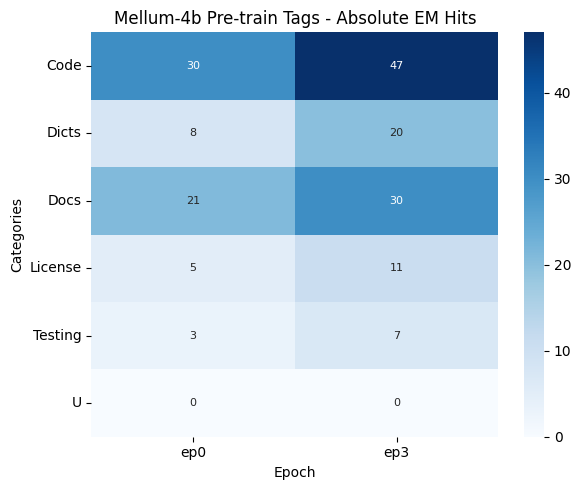

In [42]:
pre_labels = human_category_labels(pre_cat_order)
plot_heatmap(
    pre_abs,
    y_labels=pre_labels,
    title='Mellum-4b Pre-train Tags - Absolute EM Hits',
    out_pdf='./mellum-tag_mem_ptrain_absolute.pdf',
    annot=True,
    fmt='d',
)

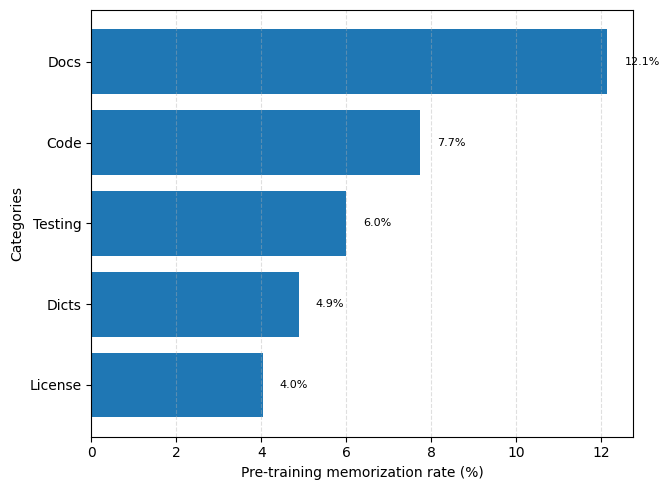

In [43]:
pre_mem_impact = pre_perc[['ep0']].copy()
pre_mem_impact = pre_mem_impact.loc[pre_mem_impact.index != 'u']
pre_mem_impact = pre_mem_impact.rename(columns={'ep0': 'Mellum-4b'})
pre_mem_impact = pre_mem_impact.sort_values('Mellum-4b', ascending=True)
pre_mem_labels = [CAT_LABELS.get(cat, cat.upper()) for cat in pre_mem_impact.index]

fig, ax = plt.subplots(figsize=(6.8, 5.0))
bars = ax.barh(pre_mem_labels, pre_mem_impact['Mellum-4b'].values, color='#1f77b4')

for bar, value in zip(bars, pre_mem_impact['Mellum-4b'].values):
    ax.text(value + 0.4, bar.get_y() + bar.get_height() / 2, f'{value:.1f}%', va='center', fontsize=8)

ax.set_xlabel('Pre-training memorization rate (%)')
ax.set_ylabel('Categories')
ax.grid(axis='x', linestyle='--', alpha=0.4)
fig.tight_layout()
fig.savefig('./mellum-tag_mem_ptrain_perc.pdf', format='pdf', bbox_inches='tight')
plt.show()

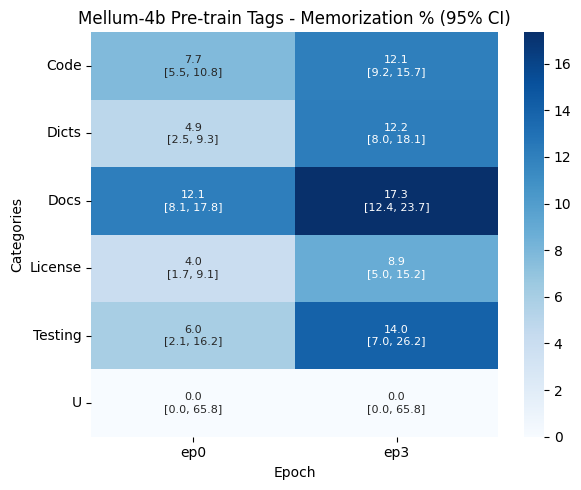

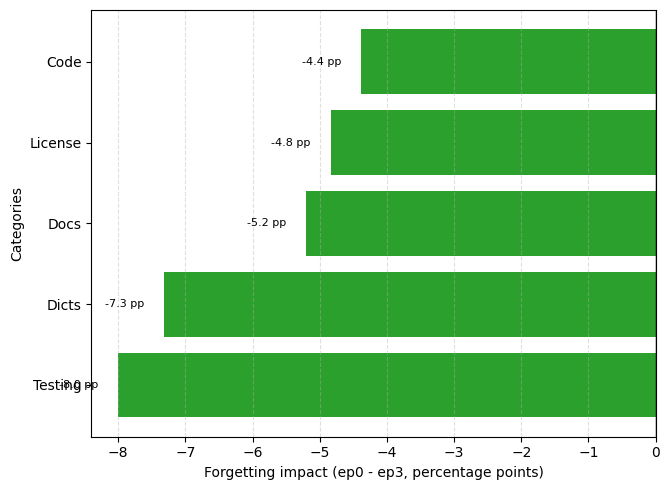

In [44]:
pre_annot_ci = ci_annotation(pre_perc, pre_ci_low, pre_ci_high, decimals=1)
plot_heatmap(
    pre_perc,
    y_labels=pre_labels,
    title='Mellum-4b Pre-train Tags - Memorization % (95% CI)',
    out_pdf='./mellum-tag_mem_ptrain_perc_with_ci_finale.pdf',
    annot=pre_annot_ci,
    fmt='',
)

pre_forgetting_impact = (pre_perc['ep0'] - pre_perc['ep3']).to_frame('Forgetting impact')
pre_forgetting_impact = pre_forgetting_impact.loc[pre_forgetting_impact.index != 'u']
pre_forgetting_impact = pre_forgetting_impact.sort_values('Forgetting impact', ascending=True)
pre_forgetting_labels = [CAT_LABELS.get(cat, cat.upper()) for cat in pre_forgetting_impact.index]
forget_values = pre_forgetting_impact['Forgetting impact'].values
forget_colors = ['#d62728' if v >= 0 else '#2ca02c' for v in forget_values]

fig, ax = plt.subplots(figsize=(6.8, 5.0))
bars = ax.barh(pre_forgetting_labels, forget_values, color=forget_colors)
ax.axvline(0, color='black', linewidth=1)

for bar, value in zip(bars, forget_values):
    x = value + 0.3 if value >= 0 else value - 0.3
    ha = 'left' if value >= 0 else 'right'
    ax.text(x, bar.get_y() + bar.get_height() / 2, f'{value:.1f} pp', va='center', ha=ha, fontsize=8)

ax.set_xlabel('Forgetting impact (ep0 - ep3, percentage points)')
ax.set_ylabel('Categories')
ax.grid(axis='x', linestyle='--', alpha=0.4)
fig.tight_layout()
fig.savefig('./mellum-tag_forgetting_ptrain_impact.pdf', format='pdf', bbox_inches='tight')
plt.show()

## Fine-tune Tags (dedup setting)

In [45]:
ft_ep0_col, ft_scope = resolve_metric_col(fine_tuning_tags, MODEL_PREFIX_FT, 'ep0', ['d3', 'dg3'])
ft_ep3_col, _ = resolve_metric_col(fine_tuning_tags, MODEL_PREFIX_FT, 'ep3', [ft_scope])

ft_cat_order = ordered_categories(fine_tuning_tags)
ft_totals, ft_abs, ft_perc, ft_ci_low, ft_ci_high = build_phase_tables(
    fine_tuning_tags,
    before_col=ft_ep0_col,
    after_col=ft_ep3_col,
    cat_order=ft_cat_order,
)

print('Fine-tune scope:', ft_scope)
print('Columns:', ft_ep0_col, ft_ep3_col)
print('Total tagged samples by category:')
display(ft_totals.to_frame('n_samples'))

print('Absolute memorization count by category (EM=1):')
display(ft_abs)

print('Memorization percentage by category:')
display(ft_perc.round(2))

print('95% Wilson CI (lower bounds, %)')
display(ft_ci_low.round(2))
print('95% Wilson CI (upper bounds, %)')
display(ft_ci_high.round(2))

Fine-tune scope: d3
Columns: me4b_ep0_d3_em me4b_ep3_d3_em
Total tagged samples by category:


,n_samples
Cat,
c,223
di,117
do,291
l,284
t,2
u,8


Absolute memorization count by category (EM=1):


,ep0,ep3
c,0,24
di,0,0
do,0,14
l,74,89
t,0,0
u,0,0


Memorization percentage by category:


,ep0,ep3
c,0.00,10.76
di,0.00,0.00
do,0.00,4.81
l,26.06,31.34
t,0.00,0.00
u,0.00,0.00


95% Wilson CI (lower bounds, %)


,ep0,ep3
c,0.0,7.34
di,0.0,0.00
do,0.0,2.89
l,21.3,26.22
t,0.0,0.00
u,0.0,0.00


95% Wilson CI (upper bounds, %)


,ep0,ep3
c,1.69,15.51
di,3.18,3.18
do,1.30,7.91
l,31.46,36.95
t,65.76,65.76
u,32.44,32.44


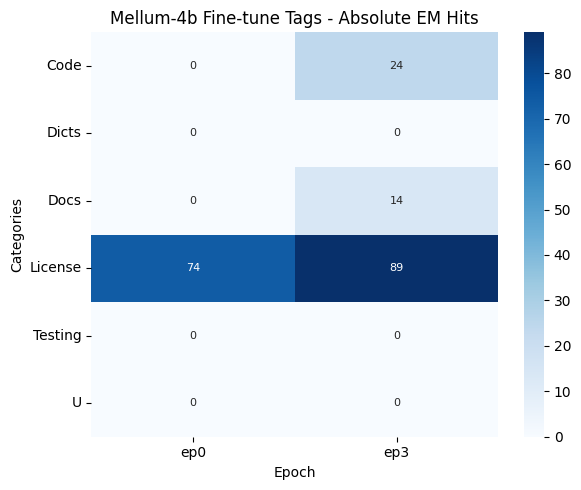

In [46]:
ft_labels = human_category_labels(ft_cat_order)
plot_heatmap(
    ft_abs,
    y_labels=ft_labels,
    title='Mellum-4b Fine-tune Tags - Absolute EM Hits',
    out_pdf='./mellum-tag_mem_ftune_absolute.pdf',
    annot=True,
    fmt='d',
)

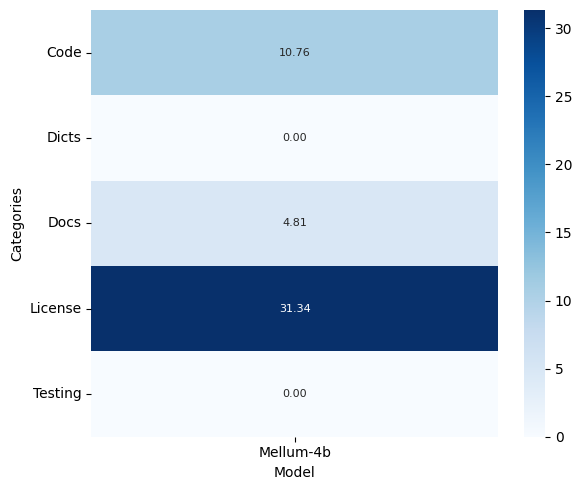

In [47]:
ft_perc_model = ft_perc[['ep3']].copy()
ft_perc_model = ft_perc_model.loc[ft_perc_model.index != 'u']
ft_perc_model = ft_perc_model.rename(columns={'ep3': 'Mellum-4b'})
ft_labels_model = human_category_labels(list(ft_perc_model.index))

plot_heatmap(
    ft_perc_model,
    y_labels=ft_labels_model,
    title='',
    out_pdf='./mellum-tag_mem_ftune_perc.pdf',
    annot=True,
    fmt='.2f',
    xlabel='Model',
)

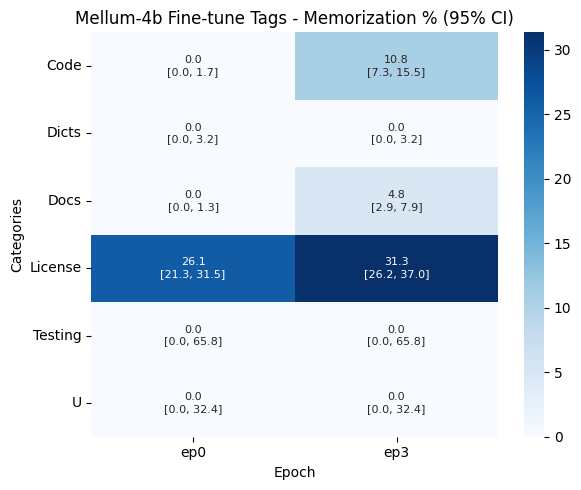

In [48]:
ft_annot_ci = ci_annotation(ft_perc, ft_ci_low, ft_ci_high, decimals=1)
plot_heatmap(
    ft_perc,
    y_labels=ft_labels,
    title='Mellum-4b Fine-tune Tags - Memorization % (95% CI)',
    out_pdf='./mellum-tag_mem_ftune_perc_with_ci_finale.pdf',
    annot=ft_annot_ci,
    fmt='',
)